# Week5 - Logistic Regression Assignment

- Run the below cells.
- Complete all of the numbered questions. You may call any packages that we've used in class.  

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

df = pd.read_csv('https://raw.githubusercontent.com/msaricaumbc/DS_data/master/ds602/log_reg/gender_classification_v7.csv')
df.head()

,long_hair,forehead_width_cm,forehead_height_cm,nose_wide,nose_long,lips_thin,distance_nose_to_lip_long,gender
0,1,11.8,6.1,1,0,1,1,Male
1,0,14.0,5.4,0,0,1,0,Female
2,0,11.8,6.3,1,1,1,1,Male
3,0,14.4,6.1,0,1,1,1,Male
4,1,13.5,5.9,0,0,0,0,Female


## Data Definitions
https://www.kaggle.com/datasets/elakiricoder/gender-classification-dataset

This dataset contains 7 features and a label column:

- **long_hair**: 0 = not long hair, 1 = long hair  
- **forehead_width_cm**: Width of the forehead in centimeters  
- **forehead_height_cm**: Height of the forehead in centimeters  
- **nose_wide**: 0 = not wide nose, 1 = wide nose  
- **nose_long**: 0 = not long nose, 1 = long nose  
- **lips_thin**: 0 = not thin lips, 1 = thin lips  
- **distance_nose_to_lip_long**: 0 = short distance, 1 = long distance between nose and lips  

- **gender**: Target label, either "Male" or "Female"


# Question 1
- What is the distribution of the target (`gender`)?  
- Do you have any concerns on class imbalances?

In [47]:
df['gender'].value_counts()
df['gender'].value_counts(normalize=True)

gender
Female    0.5001
Male      0.4999
Name: proportion, dtype: float64

COMMENTS

The target variable is almost perfectly balanced with 50.01% female and 49.99% male observations this shows that the dataset is not imbalanced since both classes are equally represented logistic regression can be trained without using resampling methods or class weighting model performance such as accuracy will be reliable and unbiased


# Question 2
- Do a quick EDA
- Can you create new features that captures the relation with the target better?

In [70]:
#  checking how big the dataset is
print("Dataset shape (rows, columns):", df.shape)
# checking the column names to know what features we have
print("\nColumn names:")
print(df.columns)
# checking if we have any missing values 
print("\nMissing values in each column:")
print(df.isnull().sum())

Dataset shape (rows, columns): (5001, 10)

Column names:
Index(['long_hair', 'forehead_width_cm', 'forehead_height_cm', 'nose_wide',
       'nose_long', 'lips_thin', 'distance_nose_to_lip_long', 'gender',
       'forehead_ratio', 'facial_feature_sum'],
      dtype='object')

Missing values in each column:
long_hair                    0
forehead_width_cm            0
forehead_height_cm           0
nose_wide                    0
nose_long                    0
lips_thin                    0
distance_nose_to_lip_long    0
gender                       0
forehead_ratio               0
facial_feature_sum           0
dtype: int64


In [71]:
df.describe()

,long_hair,forehead_width_cm,forehead_height_cm,nose_wide,nose_long,lips_thin,distance_nose_to_lip_long,forehead_ratio,facial_feature_sum
count,5001.000000,5001.000000,5001.000000,5001.000000,5001.000000,5001.000000,5001.000000,5001.000000,5001.000000
mean,0.869626,13.181484,5.946311,0.493901,0.507898,0.493101,0.498900,2.233619,2.863427
std,0.336748,1.107128,0.541268,0.500013,0.499988,0.500002,0.500049,0.264525,1.674259
min,0.000000,11.400000,5.100000,0.000000,0.000000,0.000000,0.000000,1.619718,0.000000
25%,1.000000,12.200000,5.500000,0.000000,0.000000,0.000000,0.000000,2.042857,1.000000
50%,1.000000,13.100000,5.900000,0.000000,1.000000,0.000000,0.000000,2.218750,3.000000
75%,1.000000,14.000000,6.400000,1.000000,1.000000,1.000000,1.000000,2.406780,5.000000
max,1.000000,15.500000,7.100000,1.000000,1.000000,1.000000,1.000000,3.039216,5.000000


In [72]:
# counting how many Male vs Female records we have
print("Gender counts:")
print(df['gender'].value_counts().to_string())
# printing proportions in a clean format
print("\nGender proportions:")
proportions = df['gender'].value_counts(normalize=True)
for g, p in proportions.items():
    print(f"{g}: {p:.4f}")

Gender counts:
gender
Female    2501
Male      2500

Gender proportions:
Female: 0.5001
Male: 0.4999


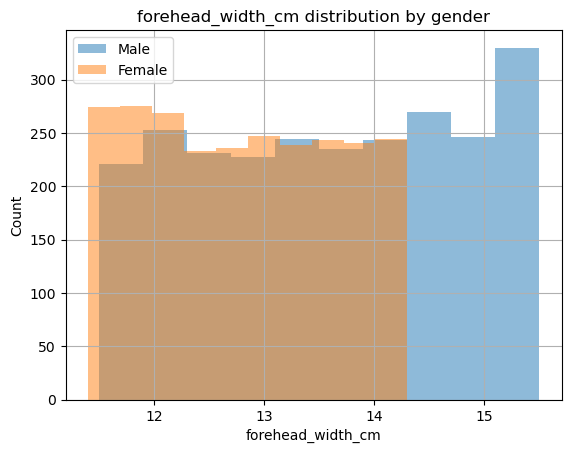

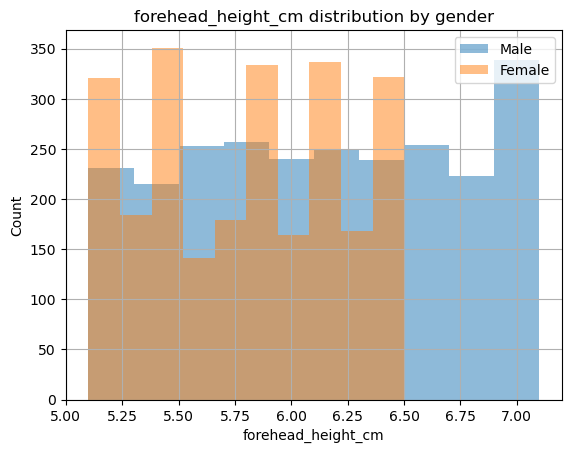

In [73]:
# the two continuous numeric features in the dataset
numeric_cols = ['forehead_width_cm', 'forehead_height_cm']
# ploting each feature’s distribution for Male vs Female
for col in numeric_cols:
    plt.figure()
    df[df['gender'] == 'Male'][col].hist(alpha=0.5, label='Male')
    df[df['gender'] == 'Female'][col].hist(alpha=0.5, label='Female')
    plt.title(f"{col} distribution by gender")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.legend()
    plt.show()

In [74]:
# plan 1: Createing a forehead "ratio"
df['forehead_ratio'] = df['forehead_width_cm'] / df['forehead_height_cm']
# plan  2: Combineing multiple binary facial features into one score
binary_cols = ['long_hair', 'nose_wide', 'nose_long', 'lips_thin', 'distance_nose_to_lip_long']
df['facial_feature_sum'] = df[binary_cols].sum(axis=1)
# checking to confirm these new columns were created properly
df[['forehead_ratio', 'facial_feature_sum']].head()

,forehead_ratio,facial_feature_sum
0,1.934426,4
1,2.592593,1
2,1.873016,4
3,2.360656,3
4,2.288136,1


In [75]:
group_means = df.groupby('gender')[[
    'forehead_width_cm',
    'forehead_height_cm',
    'forehead_ratio',
    'facial_feature_sum'
]].mean()
print(group_means)

        forehead_width_cm  forehead_height_cm  forehead_ratio  \
gender                                                          
Female          12.811675            5.796321        2.222409   
Male            13.551440            6.096360        2.244832   

        facial_feature_sum  
gender                      
Female            1.367053  
Male              4.360400  


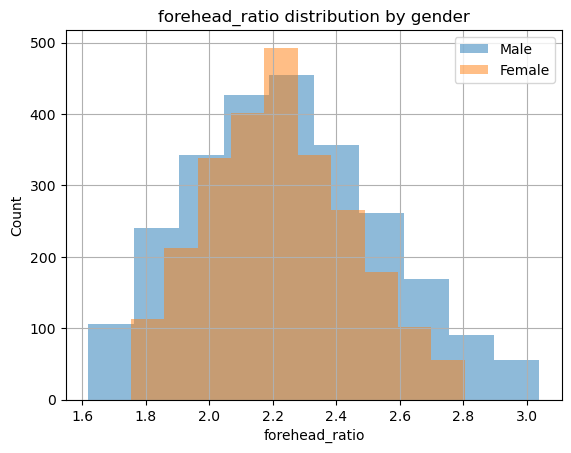

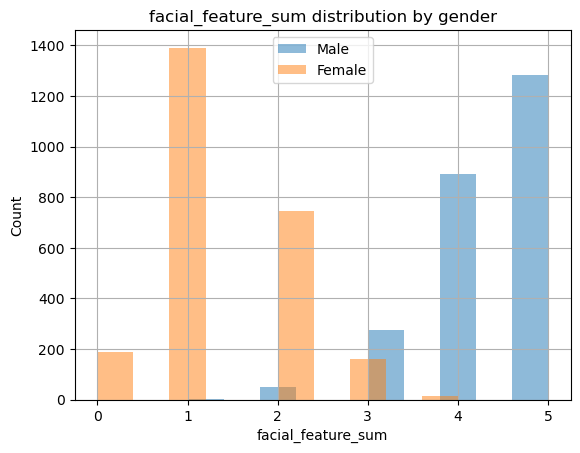

In [76]:
# Ploting the engineered features to see separation between classes
engineered_cols = ['forehead_ratio', 'facial_feature_sum']
for col in engineered_cols:
    plt.figure()
    df[df['gender'] == 'Male'][col].hist(alpha=0.5, label='Male')
    df[df['gender'] == 'Female'][col].hist(alpha=0.5, label='Female')
    plt.title(f"{col} distribution by gender")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.legend()
    plt.show()

Summarize your findings here


The EDA shows detail patterns between the features and the target variable that is the gender the numeric features like forehead width and height show slight differences between males and females but there is noticeable overlap in their distributions when we created the forehead_ratio feature the separation between genders became slightly clear males tend to have marginally higher forehead ratio values on average although the distributions still overlap significantly meaning this feature alone may not perfectly distinguish the classes

The engineered feature facial_feature_sum, which combines multiple binary facial characteristics into a one shows a much stronger relationship with gender males tend to have higher summed values while females tend to have lower values the distribution shows clearer clustering and less overlap compared to individual binary variables this suggests that combining related facial indicators captures structural differences more effectively than using them separately

Overall the feature engineering step improved the relationship between predictors and the target In particular the combined facial feature score appears to provide stronger predictive power and is likely to help improve logistic regression model performance.

# Question 3
- Create and print a list of the variables that you would treat as numerical and another list for the variables that you would treat as categorical.  
- Explain your choices.

In [77]:
# we first identify which variables should be treated as numerical
numerical_vars = [
    'forehead_width_cm',
    'forehead_height_cm',
    'forehead_ratio',          #
    'facial_feature_sum'       
]
# now identify categorical variables
categorical_vars = [
    'long_hair',
    'nose_wide',
    'nose_long',
    'lips_thin',
    'distance_nose_to_lip_long'
]
# printing the lists 
print("Numerical Variables:")
print(numerical_vars)
print("\nCategorical Variables:")
print(categorical_vars)

Numerical Variables:
['forehead_width_cm', 'forehead_height_cm', 'forehead_ratio', 'facial_feature_sum']

Categorical Variables:
['long_hair', 'nose_wide', 'nose_long', 'lips_thin', 'distance_nose_to_lip_long']


Insert comments here

The variable forehead_width_cm and forehead_height_cm are considered numerical as they are continuous measurements the variable engineered feature forehead_ratio is considered numerical as it is a combination of two continuous values the variable facial_feature_sum is considered numerical as it is a summary of facial feature counts and has a clear ordered numeric value

The variables long_hair, nose_wide, nose_long, lips_thin, and distance_nose_to_lip_long are considered categorical as they are binary, containing only 0s and 1s although they are represented numerically they are actually categorical

# Question 4
- Split the data into training and test sets.  
- Use 20% of the data for test and a random state of 124.  

In [78]:
from sklearn.model_selection import train_test_split
# defineing the target variable
y = df['gender']
# defineing the feature matrix
X = df.drop(columns=['gender'])

In [79]:
# spliting the data into training and testing sets
# 20% of the data will be used for testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=124
)
# printing the shapes to confirm the split worked correctly
print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

Training set shape: (4000, 9)
Test set shape: (1001, 9)


# Question 5
- Create a pipeline to process the numerical data.  
- Create a pipeline to process the categorical data.  

Verify each pipeline contains the columns you would expect using a fit_transform on the training data, i.e., print the shapes of the fit_transforms for each pipeline.

In [80]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
# numerical pipeline:
# standardScaler puts numeric features on a similar scale 
numerical_pipeline = Pipeline(steps=[
    ("scale", StandardScaler())
])
print("Numerical pipeline created.")

Numerical pipeline created.


In [81]:
# categorical pipeline:
# OneHotEncoder converts category/binary columns into model-friendly columns
categorical_pipeline = Pipeline(steps=[
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])
print("Categorical pipeline created.")

Categorical pipeline created.


In [82]:
# fiting and transforming only the numeric columns in the training set
X_train_num = numerical_pipeline.fit_transform(X_train[numerical_vars])
# fiting and transforminh only the categorical columns in the training set
X_train_cat = categorical_pipeline.fit_transform(X_train[categorical_vars])
# printing shapes to confirm the transformations look correct
print("Shape after numerical pipeline:", X_train_num.shape)
print("Shape after categorical pipeline:", X_train_cat.shape)

Shape after numerical pipeline: (4000, 4)
Shape after categorical pipeline: (4000, 10)


The numerical pipeline produced an output of 4000, 4 which confirms that all four numerical features were correctly selected and transformed for the 4000 training observations these features include forehead width, forehead height, the engineered forehead ratio, and the facial feature sum applying StandardScaler ensures that these continuous variables are standardized and placed on a similar scale which is important for logistic regression to perform properly

The categorical pipeline produced an output of 4000, 10 although we originally had five binary categorical variables the OneHotEncoder converts each binary feature into two separate columns this results in a total of 10 encoded columns the output shape confirms that the categorical pipeline correctly transformed all intended categorical variables overall both pipelines are processing the expected columns and preparing the data properly for modeling

# Question 6
- Create a pipeline that combines the pre-processing and implements a logistic regression model.  
- Print the accuracy on the training set and the test set.
- Do you have any concerns of overfitting based on the differences between the two accuracy scores?

In [83]:
from sklearn.compose import ColumnTransformer
# combineing the numeric and categorical pipelines into one preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numerical_pipeline, numerical_vars),
        ("cat", categorical_pipeline, categorical_vars)
    ]
)
print("Preprocessor created.")

Preprocessor created.


In [84]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
# full pipeline:
log_reg_model = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])
print("Full logistic regression pipeline created.")

Full logistic regression pipeline created.


In [85]:
# training the model on the training data
log_reg_model.fit(X_train, y_train)
# accuracy on training set
train_acc = log_reg_model.score(X_train, y_train)
# accuracy on test set
test_acc = log_reg_model.score(X_test, y_test)
print(f"Training Accuracy: {train_acc:.4f}")
print(f"Test Accuracy:     {test_acc:.4f}")

Training Accuracy: 0.9692
Test Accuracy:     0.9680


Insert comments here

The logistic regression model got a training accuracy of 96.92% and a test accuracy of 96.80% the difference between the two scores is very small indicating that the model performs consistently on both the training and test datasets since the test accuracy is nearly same to the training accuracy there is no significant evidence of overfitting the model appears to generalize well to unseen data and maintains stable predictive perform

# Question 7
Your supervisor asked you to extract learned parameters from the trained model. Give it as a dictionary. 

Another team will use these learned parameters to write a predictors in different platforms.

In [86]:
# geting the fitted preprocessor
fitted_preprocessor = log_reg_model.named_steps["preprocess"]
# geting numerical feature names 
num_features = numerical_vars
# geting categorical feature names after one-hot encoding
cat_features = fitted_preprocessor.named_transformers_["cat"] \
                                  .named_steps["onehot"] \
                                  .get_feature_names_out(categorical_vars)
# combineing all feature names in correct order
all_feature_names = list(num_features) + list(cat_features)
print("Total features after preprocessing:", len(all_feature_names))

Total features after preprocessing: 14


In [87]:
# extracting trained logistic regression model
trained_model = log_reg_model.named_steps["model"]
# geting coefficients 
coefficients = trained_model.coef_[0]
# geting intercept
intercept = trained_model.intercept_[0]
# createing dictionary mapping feature names to coefficients
params_dict = dict(zip(all_feature_names, coefficients))
# adding intercept separately
params_dict["intercept"] = intercept
# printing dictionary
params_dict

{'forehead_width_cm': np.float64(-0.16405052340297763),
 'forehead_height_cm': np.float64(1.758023815059163),
 'forehead_ratio': np.float64(1.4220830877796058),
 'facial_feature_sum': np.float64(2.3918710977523467),
 'long_hair_0': np.float64(0.892360216010032),
 'long_hair_1': np.float64(-0.734851939809107),
 'nose_wide_0': np.float64(-1.2673775116044275),
 'nose_wide_1': np.float64(1.4248857878053527),
 'nose_long_0': np.float64(-1.0445221433282892),
 'nose_long_1': np.float64(1.2020304195292146),
 'lips_thin_0': np.float64(-1.1234553627776267),
 'lips_thin_1': np.float64(1.2809636389785597),
 'distance_nose_to_lip_long_0': np.float64(-1.1091668486979125),
 'distance_nose_to_lip_long_1': np.float64(1.266675124898839),
 'intercept': np.float64(0.3588470273784407)}

The learned parameters are extracted from the trained logistic regression model after all preprocessing steps were applied through the pipeline each coefficient represents the strength and direction of the relationship between a feature and the predicted outcome a positive coefficient increases the likelihood of the predicted class while a negative coefficient decreases it the intercept represents the baseline prediction when all feature values is zero the parameters were organized into a dictionary format so that another team can easily reuse these weights to implement the same prediction formula on a different platform while maintaining consistency with the trained model

# Question 8

Implement ` predictGender(obj)` function in  `gender_prediction.html` 

In [66]:
scaler = log_reg_model.named_steps["preprocess"].named_transformers_["num"].named_steps["scale"]

print("means:", dict(zip(numerical_vars, scaler.mean_)))
print("stds:", dict(zip(numerical_vars, scaler.scale_)))

means: {'forehead_width_cm': np.float64(13.18785), 'forehead_height_cm': np.float64(5.952125), 'forehead_ratio': np.float64(2.2324363656481294), 'facial_feature_sum': np.float64(2.8595)}
stds: {'forehead_width_cm': np.float64(1.1104401728593938), 'forehead_height_cm': np.float64(0.5418352926628165), 'forehead_ratio': np.float64(0.26403986713438493), 'facial_feature_sum': np.float64(1.667860830525137)}
